In [83]:
import warnings
warnings.filterwarnings('ignore')

In [84]:
import pandas as pd
import numpy as np
import pyreadr
import joblib
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [85]:
pd.set_option('display.max_columns', 100)

In [86]:
dem_uncont = 34
rep_uncont = 31

In [87]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont)
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims

,seats,winner
0,54,Democrats
1,55,Democrats
2,49,Republicans
3,54,Democrats
4,48,Republicans
...,...,...
7995,51,Democrats
7996,52,Democrats
7997,53,Democrats
7998,51,Democrats


In [88]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 51 else (100-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,37,1,0.0125,Republicans
1,38,1,0.0125,Republicans
2,40,2,0.0250,Republicans
3,41,3,0.0375,Republicans
4,42,14,0.1750,Republicans


In [89]:
np.unique(seat_sims['seats']).shape[0]

26

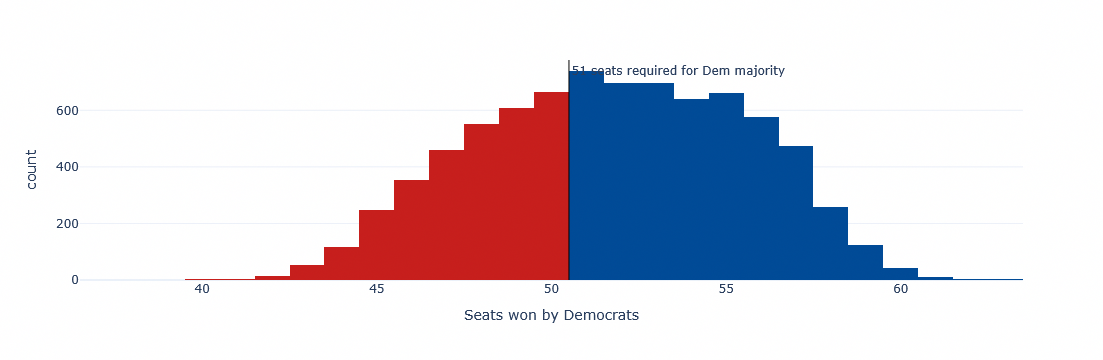

In [90]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=50.5, line_width=1, line_color='black', annotation_text='51 seats required for Dem majority', 
                    annotation_position='top right')
sims_hist

In [91]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-09-27,51.348375,US Senate,seats
1,2026-09-27,58.600000,US Senate,chance
2,2026-09-27,3.816193,US Senate,seats_sd
3,2026-09-27,38.771876,AL,y_pred
4,2026-09-27,3.537242,AL,y_pred_sd


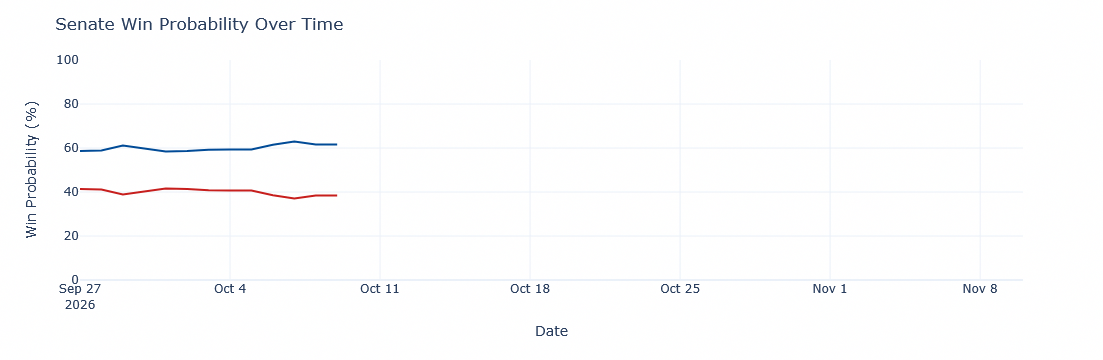

In [92]:
chance_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="Senate Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

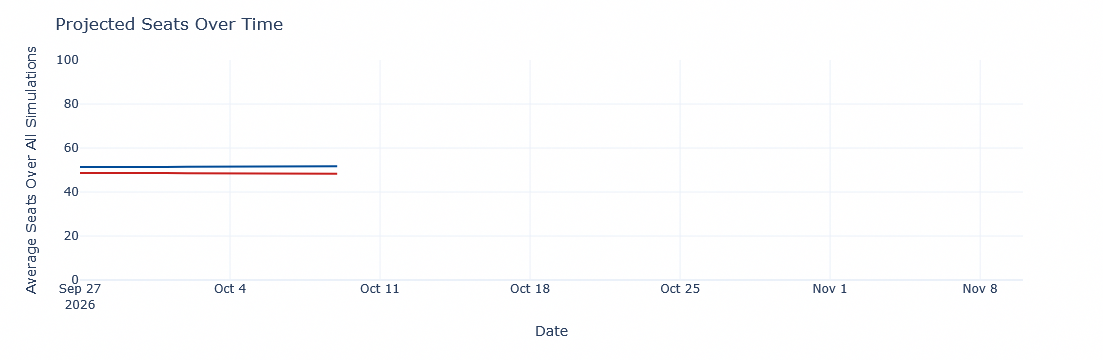

In [93]:
seats_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 100 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [94]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [95]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [96]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,7950,7951,7952,7953,7954,7955,7956,7957,7958,7959,7960,7961,7962,7963,7964,7965,7966,7967,7968,7969,7970,7971,7972,7973,7974,7975,7976,7977,7978,7979,7980,7981,7982,7983,7984,7985,7986,7987,7988,7989,7990,7991,7992,7993,7994,7995,7996,7997,7998,7999
AL,-7.892723,-13.957669,-12.150695,-12.185983,-9.869408,-13.710260,-11.742608,-5.598525,-12.680162,-17.617893,-1.422482,-13.596541,-11.435346,-11.884796,-12.446811,-9.562005,-9.878801,-12.877442,-10.293150,-7.782620,-13.170640,-9.087533,-7.258182,-9.642874,-9.322137,-14.501950,-14.080129,-8.439908,-13.324078,-13.126582,-10.616001,-12.186571,-11.846974,-8.355804,-16.368601,-15.380067,-8.183581,-11.158110,-9.036853,-12.850301,-10.877091,-9.165316,-14.267687,-10.890505,-13.131250,-13.611079,-13.221804,-15.451415,-7.956718,-11.787672,...,-11.931992,-11.229494,-10.377132,-15.418124,-7.630446,-11.753764,-13.320256,-8.192181,-12.670197,-8.508336,-16.522959,-16.555487,-10.862527,-7.557554,-17.766886,-7.415679,-16.674279,-3.388267,-12.641231,-8.892786,-11.924699,-10.273598,-4.652866,-21.857286,-3.306048,-14.721773,-12.250009,-13.575812,-8.552791,-12.629099,-11.214168,-12.903121,-11.304400,-8.304635,-16.993575,-12.815948,-11.422833,-19.032461,-10.675392,-10.179799,-11.029144,-14.598387,-10.819166,-10.713697,-12.485053,-13.555009,-15.180719,-10.292010,-12.976083,-12.502376
AK,0.666379,5.823088,0.069183,5.738196,-0.748136,4.811715,5.226985,5.557696,-0.354035,-5.430570,11.072769,0.532257,-0.921442,6.663028,-0.590883,3.387659,5.892408,4.912483,-0.184798,3.021715,7.019969,4.465445,2.539930,5.258341,4.935868,1.706160,2.651181,3.716444,-0.740793,1.890740,3.701356,5.890802,7.197039,8.474871,3.079953,0.063169,3.750253,0.322946,-0.827016,3.416927,-0.986726,3.794822,7.157781,4.334882,2.806227,-1.471471,1.124573,3.178867,2.452133,4.519322,...,4.175471,3.142302,10.196160,-0.232299,7.731075,2.959523,1.344145,3.736500,-1.263010,10.642782,2.530830,-0.741144,7.176883,3.442780,4.003172,1.717547,5.124118,2.242671,-0.534844,7.675568,1.757566,3.447448,8.736002,0.242703,4.282684,-2.315953,6.420762,5.200142,3.646447,1.161794,-3.040611,5.520828,-0.644050,6.089156,1.985131,3.150364,3.395528,7.451562,4.161761,4.147749,0.281449,4.435701,4.017622,0.552346,4.248505,0.907266,1.872195,0.713828,3.756082,1.864251
AR,-10.726562,-12.574618,-8.962944,-11.653980,-10.449755,-8.621042,-9.723598,-6.303224,-14.764648,-14.649635,-1.721219,-12.340016,-13.175238,-7.741842,-12.673726,-11.320220,-10.642186,-9.128513,-11.451213,-7.826789,-11.808096,-11.368333,-7.605113,-7.789547,-11.974852,-9.438047,-11.871676,-8.463570,-11.831410,-11.692613,-9.031633,-9.688527,-7.153366,-7.920501,-14.069163,-13.529174,-6.787580,-10.324329,-11.838424,-10.887980,-10.965456,-6.838785,-12.708849,-14.504875,-13.137328,-11.381156,-9.510599,-14.455004,-11.317474,-12.353315,...,-13.416486,-11.933306,-8.558472,-13.980078,-4.318650,-12.831493,-13.235618,-11.955212,-10.774717,-4.525699,-15.093856,-12.681199,-8.708374,-8.084817,-14.034770,-5.200930,-16.058270,-1.661779,-9.763661,-9.081434,-12.238509,-6.815068,-5.411097,-15.991480,-3.879079,-16.940813,-9.627926,-16.653361,-5.714041,-10.308899,-9.643098,-11.408990,-10.121535,-3.013373,-18.023673,-10.165176,-8.224107,-12.972479,-6.490206,-12.645657,-11.678236,-11.228629,-9.154770,-7.606246,-11.791047,-13.875916,-17.549359,-11.751689,-8.161170,-11.268767
CO,11.582360,12.363443,7.436779,14.288603,9.043222,12.725544,14.528666,13.419233,10.994336,7.319288,13.487474,13.974452,11.090829,16.354090,8.103561,15.834730,13.892187,11.976482,6.987792,6.255118,13.114499,18.871405,10.077603,16.613533,13.865472,11.659945,11.486027,20.236276,7.902947,13.699234,14.258561,10.640134,9.556838,10.661904,11.942337,5.989537,16.496564,11.384809,15.601134,9.387393,13.231022,12.210545,11.842715,13.780657,10.777113,11.913892,7.831075,11.295658,12.573313,9.717005,...,13.990388,8.820610,17.593283,10.41950

In [97]:
sim_corr = post_untransp.corr()

In [98]:
sim_corr.head()

,AL,AK,AR,CO,DE,FL,GA,ID,IL,IA,KS,KY,LA,ME,MA,MI,MN,MS,MT,NE,NH,NJ,NM,NC,OH,OK,OR,RI,SC,SD,TN,TX,VA,WV,WY
AL,1.000000,0.516676,0.740418,0.490231,0.497275,0.706495,0.532125,0.737265,0.706174,0.744515,0.737940,0.541095,0.751820,0.735758,0.523458,0.734693,0.708693,0.743865,0.702624,0.725211,0.503164,0.506890,0.506685,0.705748,0.506974,0.758512,0.507804,0.491052,0.491759,0.512090,0.557592,0.701986,0.506619,0.741314,0.739106
AK,0.516676,1.000000,0.516755,0.520908,0.524835,0.498583,0.558303,0.526722,0.505210,0.517957,0.519045,0.566298,0.523737,0.505333,0.560537,0.511283,0.499504,0.516927,0.498758,0.516427,0.561852,0.539028,0.554172,0.498112,0.553136,0.520896,0.547057,0.549477,0.538182,0.541688,0.597637,0.508649,0.544104,0.520493,0.519417
AR,0.740418,0.516755,1.000000,0.487362,0.500036,0.703510,0.526947,0.736343,0.698556,0.741851,0.737749,0.537621,0.742166,0.729130,0.523705,0.728297,0.700095,0.725730,0.694198,0.721787,0.508479,0.500745,0.501318,0.705444,0.504692,0.744418,0.501964,0.496685,0.495327,0.515451,0.556959,0.701800,0.498840,0.735849,0.735197
CO,0.490231,0.520908,0.487362,1.000000,0.708956,0.653192,0.550562,0.497654,0.653078,0.503355,0.487208,0.549391,0.503915,0.483434,0.538190,0.486994,0.642920,0.493871,0.654077,0.477494,0.710266,0.715796,0.719490,0.647698,0.704549,0.499893,0.710491,0.702526,0.699100,0.530841,0.571431,0.655979,0.703962,0.496864,0.494061
DE,0.497275,0.524835,0.500036,0.708956,1.000000,0.667154,0.543138,0.504137,0.664020,0.508823,0.499889,0.547760,0.503499,0.500108,0.549160,0.501355,0.663507,0.499228,0.665234,0.489354,0.718767,0.725938,0.728460,0.661512,0.714981,0.515674,0.710039,0.712901,0.709331,0.521158,0.577947,0.661500,0.719022,0.499430,0.509315


In [99]:
post.shape

(35, 8000)

In [100]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 51 - dem_uncont: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (51 - dem_uncont)
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (100 - seats_won_dem - dem_uncont - rep_uncont) - (50 - rep_uncont)
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [101]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:06<00:00, 1230.48it/s]


array(['IA', 'MI', 'TX', ..., 'IA', 'MA', 'AK'],
      shape=(8000,), dtype='<U32')

In [102]:
data = pd.read_csv('../../model_output/senate_predictions.csv')
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.197304,0,0,32.999181,0.507383,53.994266,0.507383,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.507383,0.712309,20.995085,-20.429138,-49.622498,0,-99.244996,38.689269,3.539791,0.0500,1,31.882751,45.756352
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.197304,0,1,50.129501,3.255487,48.295887,3.255487,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,3.255487,1.804297,-1.833614,-3.713300,49.948144,-1,99.896288,53.344649,3.406180,83.7250,2,46.662163,60.175454
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.197304,0,1,38.848065,0.794560,49.851016,0.794560,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.794560,0.891381,11.002951,-21.423739,-8.541719,-1,-17.083438,39.650316,3.569568,0.1750,3,32.557220,46.562997
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.197304,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.126440,47.730058,1,95.460117,61.936089,3.504042,99.9625,4,55.147914,68.840521
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.197304,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.219693,48.524126,1,97.048252,63.479316,3.504486,99.9875,5,56.639738,70.436399


In [103]:
data['tipping_point_prob'] = data['state_po'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.197304,0,0,32.999181,0.507383,53.994266,0.507383,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.507383,0.712309,20.995085,-20.429138,-49.622498,0,-99.244996,38.689269,3.539791,0.0500,1,31.882751,45.756352,0.0000
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.197304,0,1,50.129501,3.255487,48.295887,3.255487,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,3.255487,1.804297,-1.833614,-3.713300,49.948144,-1,99.896288,53.344649,3.406180,83.7250,2,46.662163,60.175454,4.8375
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.197304,0,1,38.848065,0.794560,49.851016,0.794560,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.794560,0.891381,11.002951,-21.423739,-8.541719,-1,-17.083438,39.650316,3.569568,0.1750,3,32.557220,46.562997,0.0000
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.197304,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.126440,47.730058,1,95.460117,61.936089,3.504042,99.9625,4,55.147914,68.840521,0.1500
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.197304,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.219693,48.524126,1,97.048252,63.479316,3.504486,99.9875,5,56.639738,70.436399,0.4750


In [104]:
data.sort_values('tipping_point_prob', ascending=False).head(5)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
15,15,Michigan,Abdul El-Sayed,Mike J. Rogers,False,False,D,MI,"EL-SAYED, ABDUL","ROGERS, MICHAEL J",14408058.06,6831818.66,21239876.72,67.834942,32.165058,-0.192456,49.278763,77.709102,2.333008,4.148895,12.968600,0.319413,32.445883,7404258,2673073,10077331,73.474395,26.525605,0.987401,-9.197304,0,0,48.172723,9.497273,45.700189,9.497273,East North Central,2026,0.0,0.00000,0.00000,2,Senate,4601.579360,9.497273,3.081765,-2.472535,8.812392,17.834942,0,35.669884,50.379269,3.539731,54.3500,16,43.603637,57.391042,10.4500
9,9,Iowa,Josh Turek,Ashley Hinson,False,False,R,IA,"TUREK, JOSHUA","ARENHOLZ, ASHLEY HINSON",5835816.67,5267628.55,11103445.22,52.558612,47.441388,-6.092833,43.277201,88.847514,1.696738,4.401391,3.028533,0.168574,31.423453,2014831,1175538,3190369,63.153541,36.846459,0.987401,-9.197304,0,0,46.248528,7.212262,45.626939,7.212262,West North Central,2026,0.0,0.00000,0.00000,3,Senate,2762.407675,7.212262,2.685566,-0.621589,-2.988362,2.558612,0,5.117224,49.933163,3.515812,48.5125,10,42.940079,56.813772,10.2250
31,31,Texas,James Talarico,Ken Paxton,False,False,R,TX,"TALARICO, JAMES","PAXTON, WARREN KENNETH JR.",65585741.88,9020177.98,74605919.86,87.909568,12.090432,-5.916874,43.060966,48.286718,4.530331,31.642337,13.173480,0.180615,33.823334,24400697,4744808,29145505,83.720275,16.279725,0.987401,-9.197304,0,0,48.865890,7.543475,44.852815,7.543475,West South Central,2026,0.0,0.25284,-0.25284,6,Senate,7728.092153,7.543475,2.746539,-4.013075,-2.636444,37.909568,0,75.819136,51.784629,3.630120,69.0625,32,44.705343,58.994559,9.7000
24,24,Ohio,Sherrod Brown,Jon Husted,False,True,R,OH,"BROWN, SHERROD","HUSTED, JON",31146133.40,6280012.05,37426145.45,83.220254,16.779746,-5.266554,44.343385,80.925356,1.708882,3.291326,11.486903,0.076606,31.487184,9001099,2798349,11799448,76.284069,23.715931,0.987401,-9.197304,0,1,47.551734,4.367143,45.022536,4.367143,East North Central,2026,0.0,0.00000,0.00000,2,Senate,6925.610718,4.367143,2.089771,-2.529198,-1.335803,33.220254,-1,66.440509,50.784201,3.470934,58.8000,25,43.900856,57.662983,9.2250
28,28,South Carolina,Annie Andrews,Darline Graham,False,False,R,SC,"ANDREWS, ANNIE","GRAHAM, DARLINE",10677209.93,299782.64,10976992.57,97.268991,2.731009,-8.282832,40.938317,67.144996,1.378347,4.124393,24.827438,0.196629,32.129153,3477869,1640556,5118425,67.948031,32.051969,0.987401,-9.197304,0,0,44.596019,1.320049,45.788282,1.320049,South Atlantic,2026,0.0,0.00000,0.00000,5,Senate,9461.256637,1.320049,1.148934,1.192263,-7.368361,47.268991,0,94.537982,49.549585,3.546733,44.7500,29,42.551461,56.488589,8.4875


In [105]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Dan Osborn', 'Brian Bengs', 'Todd Achilles', 'Seth Bodnar']
    indie_r = []
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [106]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.197304,0,0,32.999181,0.507383,53.994266,0.507383,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.507383,0.712309,20.995085,-20.429138,-49.622498,0,-99.244996,38.689269,3.539791,0.0500,1,31.882751,45.756352,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b..."
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.197304,0,1,50.129501,3.255487,48.295887,3.255487,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,3.255487,1.804297,-1.833614,-3.713300,49.948144,-1,99.896288,53.344649,3.406180,83.7250,2,46.662163,60.175454,4.8375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>..."
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.197304,0,1,38.848065,0.794560,49.851016,0.794560,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.794560,0.891381,11.002951,-21.423739,-8.541719,-1,-17.083438,39.650316,3.569568,0.1750,3,32.557220,46.562997,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<..."
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.197304,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.126440,47.730058,1,95.460117,61.936089,3.504042,99.9625,4,55.147914,68.840521,0.1500,Safe D,"<b style=""color:#366bbf;"">John Hickenlooper* (..."
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.197304,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.219693,48.524126,1,97.048252,63.479316,3.504486,99.9875,5,56.639738,70.436399,0.4750,Safe D,"<b style=""color:#366bbf;"">Chris Coons* (D)</b>..."


In [107]:
data['projected_winner'] = data['chance'].map(lambda x: 'D' if x > 50 else 'R')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.197304,0,0,32.999181,0.507383,53.994266,0.507383,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.507383,0.712309,20.995085,-20.429138,-49.622498,0,-99.244996,38.689269,3.539791,0.050,1,31.882751,45.756352,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.197304,0,1,50.129501,3.255487,48.295887,3.255487,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.255487,1.804297,-1.833614,-3.713300,49.948144,-1,99.896288,53.344649,3.406180,83.725,2,46.662163,60.175454,4.8375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.197304,0,1,38.848065,0.794560,49.851016,0.794560,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.794560,0.891381,11.002951,-21.423739,-8.541719,-1,-17.083438,39.650316,3.569568,0.175,3,32.557220,46.562997,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R


In [108]:
data['hold'] = data['projected_winner'] ==  data['current_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.197304,0,0,32.999181,0.507383,53.994266,0.507383,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.507383,0.712309,20.995085,-20.429138,-49.622498,0,-99.244996,38.689269,3.539791,0.050,1,31.882751,45.756352,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.197304,0,1,50.129501,3.255487,48.295887,3.255487,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.255487,1.804297,-1.833614,-3.713300,49.948144,-1,99.896288,53.344649,3.406180,83.725,2,46.662163,60.175454,4.8375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip


In [109]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.197304,0,0,32.999181,0.507383,53.994266,0.507383,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.507383,0.712309,20.995085,-20.429138,-49.622498,0,-99.244996,38.689269,3.539791,0.050,1,31.882751,45.756352,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.197304,0,1,50.129501,3.255487,48.295887,3.255487,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.255487,1.804297,-1.833614,-3.713300,49.948144,-1,99.896288,53.344649,3.406180,83.725,2,46.662163,60.175454,4.8375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.7
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.197304,0,1,38.848065,0.794560,49.851016,0.794560,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.794560,0.891381,11.002951,-21.423739,-8.541719,-1,-17.083438,39.650316,3.569568,0.175,3,32.557220,46.562997,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+20.7


In [110]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.197304,0,0,32.999181,0.507383,53.994266,0.507383,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.507383,0.712309,20.995085,-20.429138,-49.622498,0,-99.244996,38.689269,3.539791,0.050,1,31.882751,45.756352,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6,99.950,0.0,100.0,<1%,>99%
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.197304,0,1,50.129501,3.255487,48.295887,3.255487,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.255487,1.804297,-1.833614,-3.713300,49.948144,-1,99.896288,53.344649,3.406180,83.725,2,46.662163,60.175454,4.8375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.7,16.275,83.7,16.3,83.7%,16.3%
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.197304,0,1,38.848065,0.794560,49.851016,0.794560,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.794560,0.891381,11.002951,-21.423739,-8.541719,-1,-17.083438,39.650316,3.569568,0.175,3,32.557220,46.562997,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+20.7,99.825,0.2,99.8,<1%,>99%


In [111]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.197304,0,0,32.999181,0.507383,53.994266,0.507383,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.507383,0.712309,20.995085,-20.429138,-49.622498,0,-99.244996,38.689269,3.539791,0.050,1,31.882751,45.756352,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6,99.950,0.0,100.0,<1%,>99%,8.259761
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.197304,0,1,50.129501,3.255487,48.295887,3.255487,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.255487,1.804297,-1.833614,-3.713300,49.948144,-1,99.896288,53.344649,3.406180,83.725,2,46.662163,60.175454,4.8375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.7,16.275,83.7,16.3,83.7%,16.3%,20.382422
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.197304,0,1,38.848065,0.794560,49.851016,0.794560,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.794560,0.891381,11.002951,-21.423739,-8.541719,-1,-17.083438,39.650316,3.569568,0.175,3,32.557220,46.562997,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+20.7,99.825,0.2,99.8,<1%,>99%,10.640618


In [112]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.197304,0,0,32.999181,0.507383,53.994266,0.507383,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.507383,0.712309,20.995085,-20.429138,-49.622498,0,-99.244996,38.689269,3.539791,0.050,1,31.882751,45.756352,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6,99.950,0.0,100.0,<1%,>99%,8.259761,D+8.3
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.197304,0,1,50.129501,3.255487,48.295887,3.255487,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.255487,1.804297,-1.833614,-3.713300,49.948144,-1,99.896288,53.344649,3.406180,83.725,2,46.662163,60.175454,4.8375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.7,16.275,83.7,16.3,83.7%,16.3%,20.382422,D+20.4


In [113]:
tab_data = data[['state', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Dan Osborn', 'Brian Bengs', 
                                                                                              'Todd Achilles', 'Seth Bodnar'] else x)
tab_data = tab_data.rename({
    'state': 'State',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,State,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,Alabama,Everett Weiss,Barry Moore,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+22.6,D+8.3,0.0000
1,Alaska,Mary Peltola,Dan S. Sullivan,Likely D,"<p style=""color:blue;"">83.7%</p>","<p style=""color:red;"">16.3%</p>",D+6.7,D+20.4,4.8375
2,Arkansas,Hallie Shoffner,Tom Cotton,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+20.7,D+10.6,0.0000
3,Colorado,John Hickenlooper,Mark Baisley,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+23.9,D+12.6,0.1500
4,Delaware,Chris Coons,Michael Katz,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+27.0,D+12.0,0.4750


In [114]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

8.438767176246794

In [115]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,51.708875
1,chamber_win_chance,61.587500
0,sv_bias,8.438767


In [116]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [117]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 100 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,61.5875,51.708875
1,Republicans,38.4125,48.291125


In [118]:
incl_cols = ['state', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = data[incl_cols]

In [119]:
rating_ts = output_ts[output_ts['type'] == 'chance']
rating_ts['rating'] = rating_ts['y'].map(get_rating)
rating_ts['date'] = pd.to_datetime(rating_ts['date'])
rating_ts.head()

,date,y,geo,type,rating
1,2026-09-27,58.6000,US Senate,chance,Tossup
5,2026-09-27,0.0500,AL,chance,Safe R
10,2026-09-27,79.8875,AK,chance,Likely D
15,2026-09-27,0.1250,AR,chance,Safe R
20,2026-09-27,99.9625,CO,chance,Safe D


In [120]:
## Alert when there's a rating change
today_date = rating_ts['date'].max()
yesterday = rating_ts[rating_ts['date'] != today_date]['date'].max()

today_ratings = rating_ts[rating_ts['date'] == today_date]
yester_ratings = rating_ts[rating_ts['date'] == yesterday]
compare_df = pd.merge(left=today_ratings, right=yester_ratings, on='geo', how='left', suffixes=['_t', '_y'])
compare_df.head()

,date_t,y_t,geo,type_t,rating_t,date_y,y_y,type_y,rating_y
0,2026-10-09,61.5875,US Senate,chance,Tilt D,2026-10-08,61.6125,chance,Tilt D
1,2026-10-09,0.0500,AL,chance,Safe R,2026-10-08,0.0500,chance,Safe R
2,2026-10-09,83.7250,AK,chance,Likely D,2026-10-08,83.8500,chance,Likely D
3,2026-10-09,0.1750,AR,chance,Safe R,2026-10-08,0.1250,chance,Safe R
4,2026-10-09,99.9625,CO,chance,Safe D,2026-10-08,99.9625,chance,Safe D


In [121]:
## This is the cell that actually alerts when there's a rating change
if any(compare_df['rating_t'] != compare_df['rating_y']):
    changes_df = compare_df[compare_df['rating_t'] != compare_df['rating_y']][['geo', 'rating_y', 'rating_t']]
    print(changes_df)
else:
    print("No rating changes today!")

No rating changes today!


In [122]:
if any(compare_df['rating_t'] != compare_df['rating_y']):
    print(changes_df.shape)

In [123]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')